# <!-- TITLE --> A WGAN-GP to Draw a Sheep
<!-- DESC --> Part 2: Draw me a sheep, revisited with a WGAN-GP

## Objectives :
 - Build and train a WGAN-GP model with the Quick Draw dataset
 - Understanding WGAN-GP

The [Quick draw dataset](https://quickdraw.withgoogle.com/data) contains about 50.000.000 drawings, made by real people...  
We are using a subset of 117.555 of Sheep drawings  
To get the dataset : [https://github.com/googlecreativelab/quickdraw-dataset](https://github.com/googlecreativelab/quickdraw-dataset)  
Datasets in numpy bitmap file : [https://console.cloud.google.com/storage/quickdraw_dataset/full/numpy_bitmap](https://console.cloud.google.com/storage/quickdraw_dataset/full/numpy_bitmap)   
Sheep dataset : [https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sheep.npy](https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sheep.npy) (94.3 Mo)


## What we're going to do :

 - Have a look to the dataset
 - Defining a GAN model
 - Build the model
 - Train it
 - Analyze the results

 
<img width="800px" src="./img/sheep2.png"></img>

## Acknowledgements :
Thanks to **François Chollet** who is at the base of this example.  
See : [https://keras.io/examples/](https://keras.io/examples/)


## Step 1 - Init python stuff

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import sys

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import TensorBoard

import fidle

from modules.models.WGANGP import WGANGP
from modules.callbacks import ImagesCallback

## Step 2 - Parameters
`scale` : With scale=1, we need 5-6 minutes on a GPU V100 ...and >2h on a CPU !  
`latent_dim` : Latent space dimension, 128 for example !  
`fit_verbosity` : verbosity during training : 0 = silent, 1 = progress bar, 2 = one line per epoch  
`num_img` : Number of images to visualize

**Notes:**
- The settings below (scale=0.01) allow the notebooks to run on a laptop, but not to get a minimal result!  
- For a decent result, you need something like: scale=1. 
- The convergence being much better, epochs can here remain at epochs=3 :-)

In [5]:
latent_dim    = 128

scale         = 0.1
epochs        = 5
n_critic      = 2
batch_size    = 64
num_img       = 12
fit_verbosity = 1

## Step 3 - Load dataset and have a look 
Load sheeps as numpy bitmaps...

In [6]:
datasets_dir = 'quickdraw_data'

In [7]:
# Load dataset
x_data = np.load(datasets_dir+'/sheep.npy')
print('Original dataset shape : ',x_data.shape)

# Rescale
n=int(scale*len(x_data))
x_data = x_data[:n]
print('Rescaled dataset shape : ',x_data.shape)

# Normalize, reshape and shuffle
x_data = x_data/255
x_data = x_data.reshape(-1,28,28,1)
np.random.shuffle(x_data)
print('Final dataset shape    : ',x_data.shape)


Original dataset shape :  (126121, 784)
Rescaled dataset shape :  (12612, 784)
Final dataset shape    :  (12612, 28, 28, 1)


...and have a look :  
Note : These sheep are sheep drawn ... by real humans!

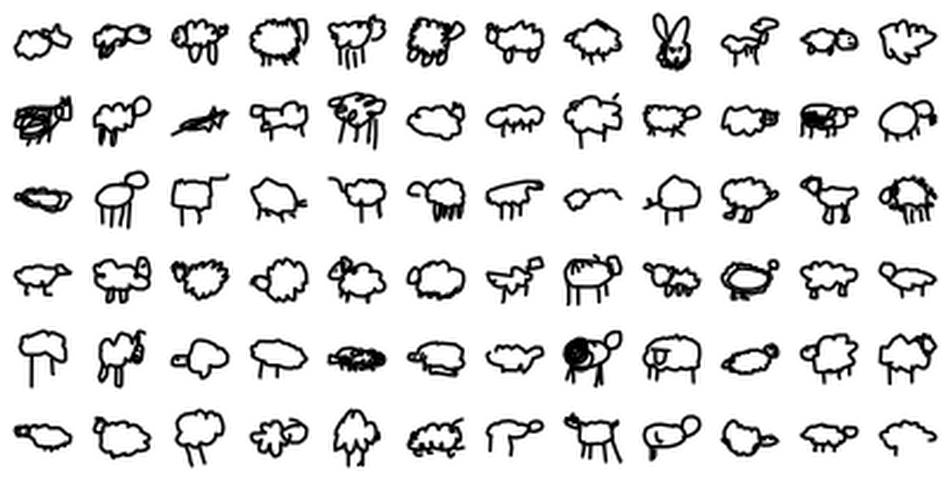

In [8]:
fidle.scrawler.images( x_data.reshape(-1,28,28), indices=range(72), columns=12, x_size=1, y_size=1, 
                     y_padding=0,spines_alpha=0, save_as='01-Sheeps')

## Step 4 - Create a discriminator

In [9]:
inputs  = keras.Input(shape=(28, 28, 1))
x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x)
c       = layers.Dense(1)(x)
# same discriminator architecture as in DCGAN,
# but without sigmoid activation at the end, and with a dropout layer before the output

discriminator = keras.Model(inputs, c, name="discriminator")
discriminator.summary()

c:\Users\admin\Desktop\GEN ai\TP-3\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,609 (1.51 MB)

 Trainable params: 396,609 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 - Create a generator

In [10]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64)(inputs)
x       = layers.Reshape((7, 7, 64))(x)
x       = layers.UpSampling2D()(x)
x       = layers.Conv2D(128,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
x       = layers.UpSampling2D()(x)
x       = layers.Conv2D(256,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation='sigmoid')(x)

generator = keras.Model(inputs, outputs, name="generator")
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 779,969 (2.98 MB)

 Trainable params: 779,969 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 - Build, compile and train our DCGAN 
Duration : 5' on a V100, with : scale=0.5, epochs=10, n_critic=2
First, clean saved images :

In [11]:
!rm $run_dir/images/*.jpg >/dev/null 2>&1 

Le chemin d'acc�s sp�cifi� est introuvable.


Build our model :

In [12]:
gan = WGANGP(discriminator=discriminator, generator=generator, latent_dim=latent_dim, n_critic=n_critic)

Fidle WGANGP is ready :-)  latent dim = 128


In [13]:
gan.compile(
#     discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
#     generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001)
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9),
    generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
)

Add a callback to save images, train our DCGAN model and save it :

In [14]:
run_dir = '.'

In [15]:
imagesCallback = ImagesCallback(num_img=num_img, latent_dim=latent_dim, run_dir=f'{run_dir}/images')

history = gan.fit( x_data, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback], 
                   verbose=fit_verbosity )

gan.save(f'{run_dir}/models/model.h5')

Epoch 1/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - d_loss: -3.4866 - g_loss: 1.7306
Epoch 2/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - d_loss: -1.8751 - g_loss: 9.2489
Epoch 3/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - d_loss: -1.2722 - g_loss: 7.0057
Epoch 4/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - d_loss: -1.1253 - g_loss: 7.1209
Epoch 5/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - d_loss: -1.0725 - g_loss: 4.9419


## Step 7 - History

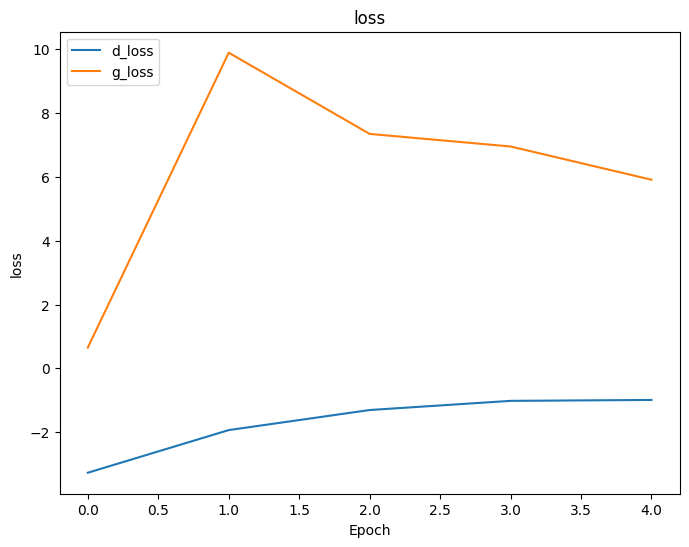

In [13]:
fidle.scrawler.history(history,  plot={'loss':['d_loss','g_loss']}, save_as='01-history')

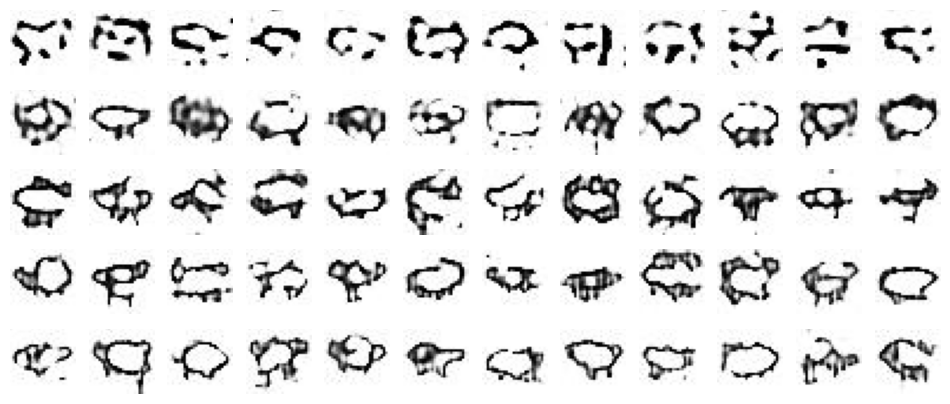

In [14]:
images=[]
for epoch in range(0,epochs,1):
    for i in range(num_img):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image    = io.imread(filename)
        images.append(image)      

fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')

## Step 8 - Generation
Reload our saved model :

In [15]:
gan.reload(f'{run_dir}/models/model.h5')

Reloaded.


Generate somes images from latent space :

In [16]:
nb_images = 12*15

z = np.random.normal(size=(nb_images,latent_dim))
images = gan.predict(z, verbose=0)


Plot it :

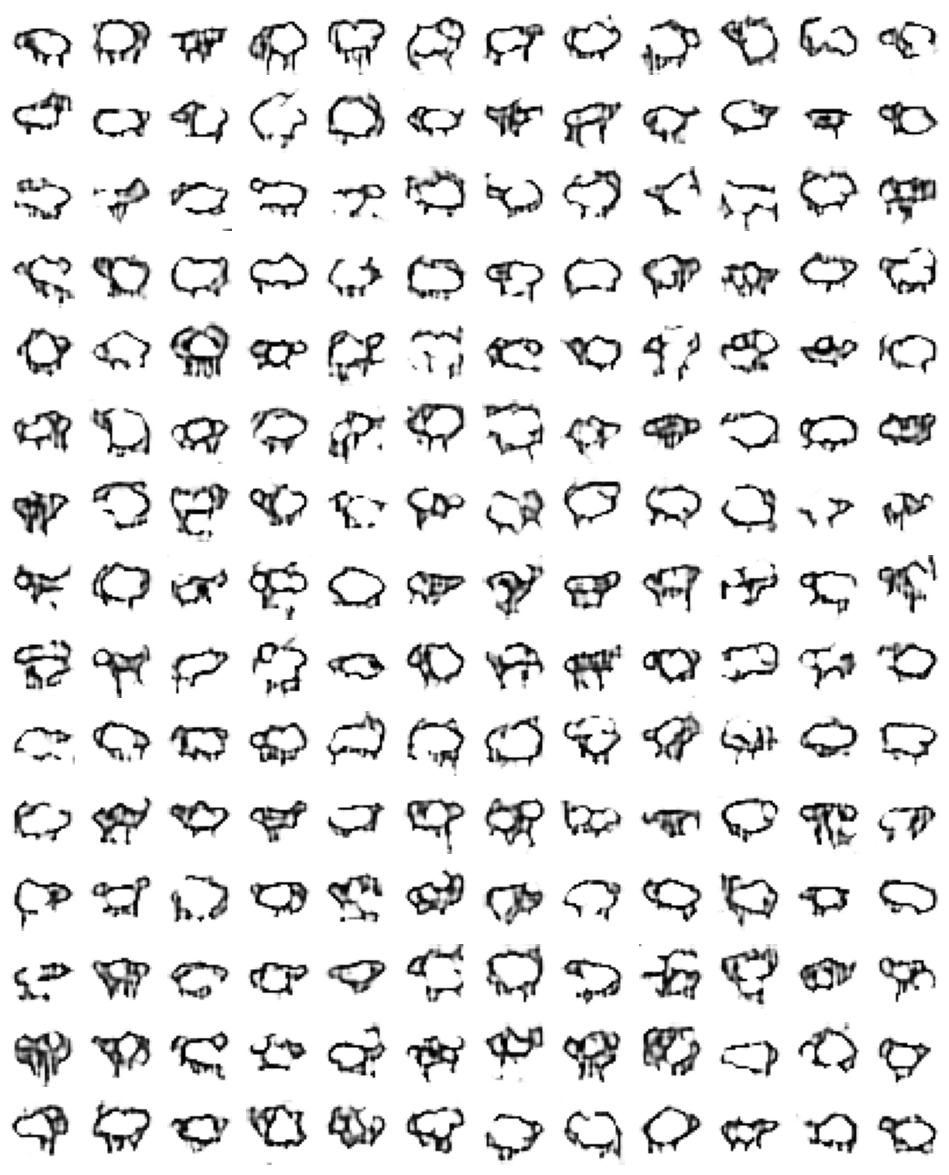

In [17]:
fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')